In [1]:
"""
Feature Selection & Advanced Modeling

Our One-Hot Encoding process created a massive, highly sparse feature space (thousands of features). To combat the "Curse of Dimensionality", prevent overfitting, and improve computational efficiency, this notebook explores three distinct paradigms of Feature Selection. We then apply Hyperparameter Tuning and advanced Gradient Boosting to maximize minority class detection.

Key steps:
+ Fast statistical evaluation using ANOVA F-values;
+ Using Lasso-style penalty in Logistic Regression to shrink non-predictive coefficients to exactly zero;
+ Recursive Feature Eliminating using a Random Forest estimator to iteratively drop the least important features;
+ Optimizing the Random Forest architecture using 5-fold cross-validation;
+ Deploying extreme gradient boosting with dynamic class weighting to handle the extreme Oscar winner imbalance.
"""

import pandas as pd
import time
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_curve, \
    average_precision_score
from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
warnings.filterwarnings('ignore')  # Suppress convergence warnings that may occur during aggressive L1 regularization

df = pd.read_csv('../data/processed/oscar_tmdb_cleaned.csv')

In [3]:
numeric_df = df.select_dtypes(include='number')

In [4]:
x = numeric_df.drop(columns=['is_oscar_winner', 'id'], errors='ignore').fillna(0)
y = df['is_oscar_winner']

In [5]:
# Stratified split to maintain the precise ratio of Oscar winners in both sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [6]:
"""
Filter methods are fast and model-agnostic. We use ANOVA F-value to score features individually against the target, selecting the top 100 most statistically significant features.
"""

selector = SelectKBest(score_func=f_classif, k=100)

In [7]:
x_train_selected = selector.fit_transform(x_train, y_train)

x_test_selected = selector.transform(x_test)

In [8]:
x_train_selected.shape[1]  # Features remaining after SelectKBest

100

In [9]:
start_time = time.time()

rf_model_top100 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_top100.fit(x_train_selected, y_train)

train_time = time.time() - start_time

train_time

0.1262369155883789

In [10]:
y_pred_top100 = rf_model_top100.predict(x_test_selected)

In [11]:
# Model result AFTER Filter Feature Selection (SelectKBest-100)

print(f"Accuracy: {accuracy_score(y_test, y_pred_top100):.4f}")

report_dict = classification_report(y_test, y_pred_top100, output_dict=True)
report_df = pd.DataFrame(report_dict).T

report_df.round(3)

Accuracy: 0.6396


,precision,recall,f1-score,support
0,0.652,0.875,0.747,120.00
1,0.583,0.273,0.372,77.00
accuracy,0.640,0.640,0.640,0.64
macro avg,0.618,0.574,0.560,197.00
weighted avg,0.625,0.640,0.601,197.00


In [12]:
selected_indices = selector.get_support(indices=True)  # The top 20 features selected by the ANOVA test
top_features = x.columns[selected_indices].tolist()

top_features[:20]

['popularity',
 'revenue',
 'runtime',
 'vote_average',
 'vote_count',
 'genre_comedy',
 'genre_history',
 'genre_music',
 'genre_war',
 'key_aids',
 'key_alcoholism',
 'key_anti_semitism',
 'key_archaeologist',
 'key_archeology',
 'key_attack',
 'key_becoming_an_adult',
 'key_betrayal',
 'key_breaking_the_fourth_wall',
 'key_british_army',
 'key_british_secret_service']

In [13]:
"""
L1 regularization penalizes the absolute value of coefficients. This acts as an intrinsic feature selector because it forces the weights of non-predictive features to become exactly zero. Linear models require feature scaling for regularization to work correctly.
"""

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [14]:
# C=0.05 controls the regularization strength (lower values mean stronger penalty/fewer features)
l1_model = LogisticRegression(penalty='l1', solver='liblinear', random_state=42, C=0.05)
selector_l1 = SelectFromModel(l1_model)

x_train_l1 = selector_l1.fit_transform(x_train_scaled, y_train)
x_test_l1 = selector_l1.transform(x_test_scaled)

In [15]:
x_train_l1.shape[1]  # Features surviving L1 Regularization

150

In [16]:
rf_model_l1 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_l1.fit(x_train_l1, y_train)

y_pred_l1 = rf_model_l1.predict(x_test_l1)

In [17]:
# Model results AFTER Embedded Feature Selection (L1)

print(f"Accuracy: {accuracy_score(y_test, y_pred_l1):.4f}")

report_dict_l1 = classification_report(y_test, y_pred_l1, output_dict=True)
report_df_l1 = pd.DataFrame(report_dict_l1).T
report_df_l1.round(3)

Accuracy: 0.6701


,precision,recall,f1-score,support
0,0.671,0.900,0.769,120.00
1,0.667,0.312,0.425,77.00
accuracy,0.670,0.670,0.670,0.67
macro avg,0.669,0.606,0.597,197.00
weighted avg,0.669,0.670,0.634,197.00


In [18]:
selected_indices_l1 = selector_l1.get_support(indices=True)
top_features_l1 = x.columns[selected_indices_l1].tolist()

top_features_l1

['budget',
 'revenue',
 'runtime',
 'vote_average',
 'genre_music',
 'genre_romance',
 'key_1970s',
 'key_affair',
 'key_aids',
 'key_alcoholism',
 'key_anti_hero',
 'key_anti_semitism',
 'key_arranged_marriage',
 'key_artist',
 'key_author',
 'key_basement',
 'key_becoming_an_adult',
 'key_beheading',
 'key_betrayal',
 'key_box',
 'key_breaking_the_fourth_wall',
 'key_british_army',
 'key_british_secret_service',
 'key_broom',
 'key_cancer',
 'key_cave',
 'key_chase',
 'key_child_abuse',
 'key_collapse',
 'key_colony',
 'key_compass',
 'key_control',
 'key_crime_fighter',
 'key_death_threat',
 'key_decision',
 'key_desert',
 'key_detroit',
 'key_disguise',
 'key_dragon',
 'key_drink',
 'key_duke',
 'key_fbi',
 'key_film_director',
 'key_film_noir',
 'key_film_producer',
 'key_finances',
 'key_first_time',
 'key_flying_saucer',
 'key_fort',
 'key_friend',
 'key_friends',
 'key_gang',
 'key_gangster_boss',
 'key_globalization',
 'key_gore',
 'key_gorilla',
 'key_governance',
 'key_great

In [19]:
"""
RFE is computationally expensive but highly accurate. It trains the model, looks at feature importances, drops the weakest ones (step=200), and repeats the process until the desired number of features (n_features_to_select=50) is reached.
"""

estimator_rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

selector_rfe = RFE(estimator=estimator_rf, n_features_to_select=50, step=200)

In [20]:
start_time = time.time()

x_train_rfe = selector_rfe.fit_transform(x_train, y_train)
x_test_rfe = selector_rfe.transform(x_test)

rfe_time = time.time() - start_time

rfe_time

3.007892608642578

In [21]:
rf_model_rfe = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_rfe.fit(x_train_rfe, y_train)

y_pred_rfe = rf_model_rfe.predict(x_test_rfe)

In [22]:
# Model results AFTER Wrapper Feature Selection (RFE)

print(f"Accuracy: {accuracy_score(y_test, y_pred_rfe):.4f}")

report_dict_rfe = classification_report(y_test, y_pred_rfe, output_dict=True)
report_df_rfe = pd.DataFrame(report_dict_rfe).T
report_df_rfe.round(3)

Accuracy: 0.6751


,precision,recall,f1-score,support
0,0.687,0.858,0.763,120.000
1,0.638,0.390,0.484,77.000
accuracy,0.675,0.675,0.675,0.675
macro avg,0.662,0.624,0.623,197.000
weighted avg,0.668,0.675,0.654,197.000


In [23]:
selected_indices_rfe = selector_rfe.get_support(indices=True)
top_features_rfe = x.columns[selected_indices_rfe].tolist()

top_features_rfe

['budget',
 'popularity',
 'revenue',
 'runtime',
 'vote_average',
 'vote_count',
 'genre_action',
 'genre_adventure',
 'genre_animation',
 'genre_comedy',
 'genre_crime',
 'genre_drama',
 'genre_family',
 'genre_fantasy',
 'genre_history',
 'genre_horror',
 'genre_music',
 'genre_mystery',
 'genre_romance',
 'genre_science_fiction',
 'genre_thriller',
 'genre_war',
 'genre_western',
 'key_aftercreditsstinger',
 'key_author',
 'key_based_on_novel',
 'key_biography',
 'key_cancer',
 'key_corruption',
 'key_detroit',
 'key_duringcreditsstinger',
 'key_dying_and_death',
 'key_dystopia',
 'key_friends',
 'key_friendship',
 'key_independent_film',
 'key_los_angeles',
 'key_love',
 'key_love_of_ones_life',
 'key_marriage_crisis',
 'key_money',
 'key_musical',
 'key_oscar_award',
 'key_paris',
 'key_patriotism',
 'key_resistance',
 'key_sport',
 'key_suicide_attempt',
 'key_violence',
 'key_woman_director']

In [24]:
"""
Optimizing the Random Forest on the RFE-selected feature space. We use a 5-fold cross-validation and aim to maximize the 'f1' score, which balances Precision and Recall for our imbalanced classes.
"""

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', 'balanced_subsample']
}

In [25]:
rf_base = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)

In [26]:
start_time = time.time()

grid_search.fit(x_train_rfe, y_train)
tune_time = time.time() - start_time

tune_time

Fitting 5 folds for each of 72 candidates, totalling 360 fits


23.825257301330566

In [27]:
best_rf = grid_search.best_estimator_

grid_search.best_params_

{'class_weight': 'balanced_subsample',
 'max_depth': 10,
 'min_samples_split': 10,
 'n_estimators': 100}

In [28]:
y_pred_best = best_rf.predict(x_test_rfe)

In [29]:
# Model results AFTER Hyperparameter Tuning (GridSearchCV)

print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")

report_dict_best = classification_report(y_test, y_pred_best, output_dict=True)
report_df_best = pd.DataFrame(report_dict_best).T
report_df_best.round(3)

Accuracy: 0.6650


,precision,recall,f1-score,support
0,0.714,0.750,0.732,120.000
1,0.577,0.532,0.554,77.000
accuracy,0.665,0.665,0.665,0.665
macro avg,0.646,0.641,0.643,197.000
weighted avg,0.661,0.665,0.662,197.000


In [30]:
"""
XGBoost is natively robust against class imbalance. We calculate the ratio of negative (non-winner) to positive (winner) instances and pass it to 'scale_pos_weight'. This severely penalizes the model for missing an Oscar winner.
"""

weight = (y_train == 0).sum() / (y_train == 1).sum()
weight.tolist()  # Imbalance ratio

1.5419354838709678

In [31]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

In [32]:
start_time = time.time()

xgb_model.fit(x_train_rfe, y_train)
xgb_time = time.time() - start_time

xgb_time

1.31982421875

In [33]:
y_pred_xgb = xgb_model.predict(x_test_rfe)

In [34]:
# Model results: XGBoost applied to RFE-selected features

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")

report_dict_xgb = classification_report(y_test, y_pred_xgb, output_dict=True)
report_df_xgb = pd.DataFrame(report_dict_xgb).T
report_df_xgb.round(3)

Accuracy: 0.6548


,precision,recall,f1-score,support
0,0.717,0.717,0.717,120.000
1,0.558,0.558,0.558,77.000
accuracy,0.655,0.655,0.655,0.655
macro avg,0.638,0.638,0.638,197.000
weighted avg,0.655,0.655,0.655,197.000


In [35]:
# Set aesthetic style for the plots
sns.set_theme(style="whitegrid")

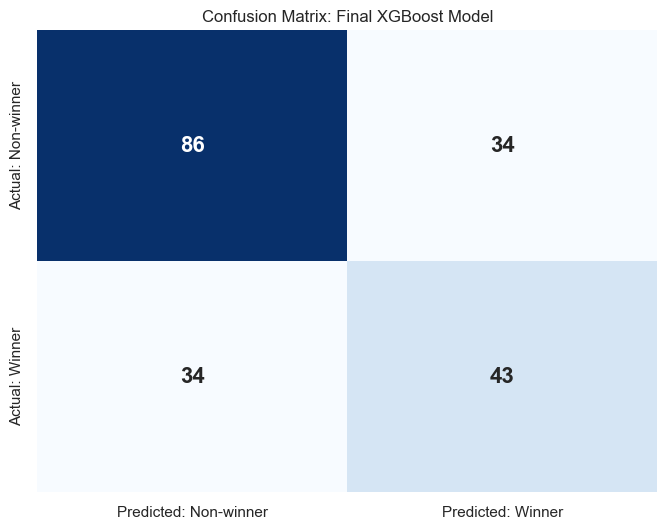

In [36]:
"""
The Confusion Matrix is critical for imbalanced datasets. It shows exactly where the model is making mistakes:
- False Positives: Non-winners predicted as winners;
- False Negatives: Real Oscar winners that the model missed.
"""

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={'size': 16, 'weight': 'bold'},
            xticklabels=['Predicted: Non-winner', 'Predicted: Winner'],
            yticklabels=['Actual: Non-winner', 'Actual: Winner'])
plt.title('Confusion Matrix: Final XGBoost Model')
plt.show()

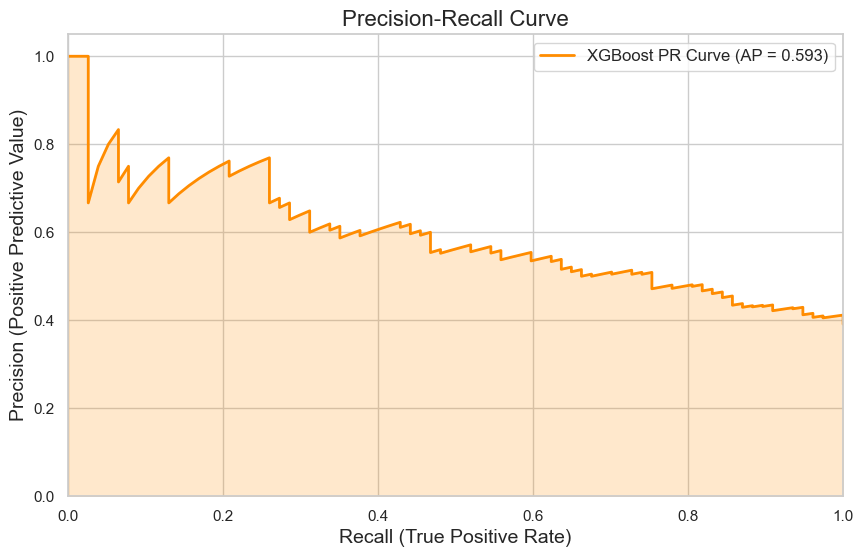

In [37]:
"""
Because our classes are heavily imbalanced (93% vs 7%), a standard ROC curve can be misleadingly optimistic. The Precision-Recall (PR) curve is the industry standard for visualizing the trade-off in anomaly detection tasks.
"""

# We need predicted probabilities (not just 0/1 classes) for the curve
y_probs_xgb = xgb_model.predict_proba(x_test_rfe)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_probs_xgb)
avg_precision = average_precision_score(y_test, y_probs_xgb)

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, color='darkorange', lw=2, label=f'XGBoost PR Curve (AP = {avg_precision:.3f})')

plt.fill_between(recall, precision, alpha=0.2, color='darkorange')
plt.title('Precision-Recall Curve', fontsize=16)
plt.xlabel('Recall (True Positive Rate)', fontsize=14)
plt.ylabel('Precision (Positive Predictive Value)', fontsize=14)
plt.legend(loc="upper right", fontsize=12)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.show()

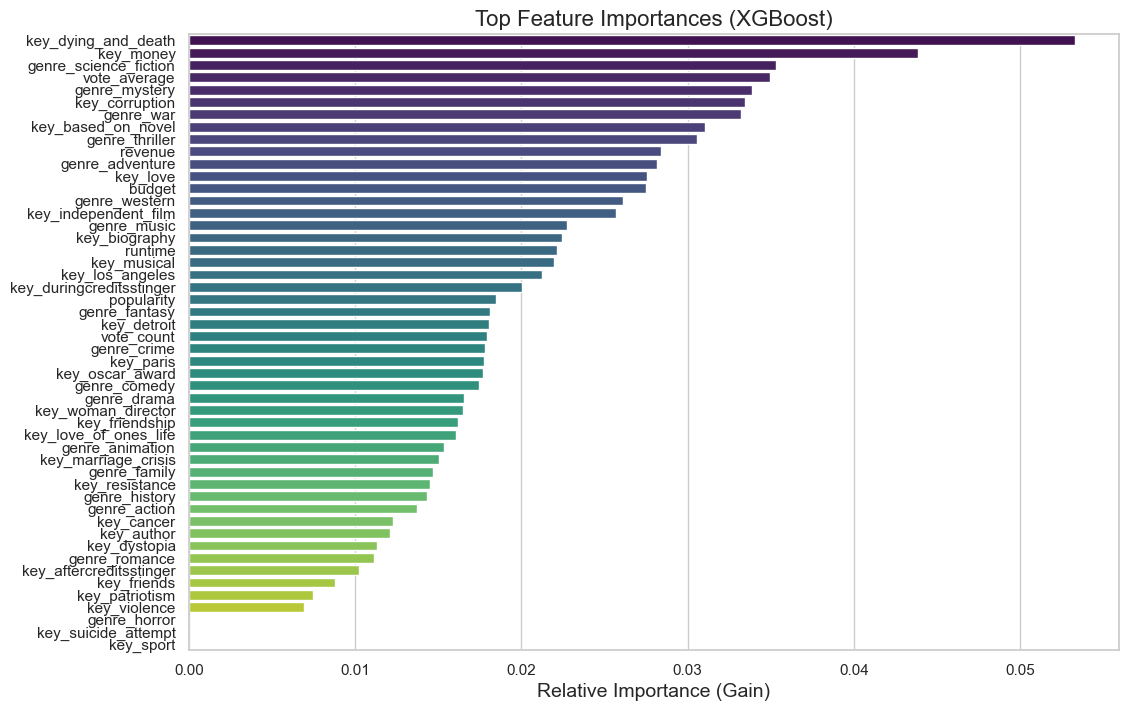

In [38]:
"""
Extracting the internal logic of the XGBoost model. This shows which features mathematically contributed the most to separating Oscar winners from the rest of the dataset.
"""

# Extract feature importances and map them to column names
importances = xgb_model.feature_importances_
feature_names = top_features_rfe  # Using the feature names saved from the RFE step

# Create a DataFrame and sort by importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=importance_df, palette='viridis', legend=False)

plt.title('Top Feature Importances (XGBoost)', fontsize=16)
plt.xlabel('Relative Importance (Gain)', fontsize=14)
plt.ylabel('')
plt.show()